# Stellarator Long-Run Analysis: Trim → Statistics

This notebook walks through the full quends workflow for four stellarator gyrokinetic simulation runs (`long_run_a` through `long_run_d`):

1. **Load** each CSV into a `DataStream`
2. **Inspect** the raw signals
3. **Trim** the transient startup phase — all six available strategies are demonstrated
4. **Compare** strategy-detected steady-state start times side-by-side
5. **Compute statistics** (mean, uncertainty, confidence interval, ESS) on the trimmed data
6. **Summarise** results in a comparison table

The primary column of interest is `HeatFlux_st` (turbulent heat flux), though the same workflow applies to any column.

## 1 — Setup

In [25]:
# ── Local development path setup ─────────────────────────────────────────────
# This cell makes the notebook work directly from the repo without installing
# quends as a package.  It walks up the directory tree from the current working
# directory until it finds a folder that contains src/quends/, then prepends
# that src/ directory to sys.path.
import sys
from pathlib import Path

def _find_src(start: Path) -> Path:
    """Walk up from *start* until src/quends/ is found; return the src/ path."""
    for directory in [start, *start.parents]:
        candidate = directory / "src" / "quends"
        if candidate.is_dir():
            return directory / "src"
    raise RuntimeError(
        "Could not find src/quends/ in any parent of the current directory.\n"
        f"Searched from: {start}\n"
        "Make sure you open Jupyter from inside the quends_main_2 repo."
    )

_src = _find_src(Path.cwd())
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

print(f"quends source: {_src}")

quends source: /Users/eehoward/Desktop/ALL_Projects/QUENDS_CC/quends_main_2/src


In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quends import DataStream, from_csv
from quends import (
    IQRTrimStrategy,
    MeanVariationTrimStrategy,
    NoiseThresholdTrimStrategy,
    QuantileTrimStrategy,
    RollingVarianceThresholdTrimStrategy,
    SelfConsistentTrimStrategy,
    TrimDataStreamOperation,
)

In [27]:
# ── Path configuration ────────────────────────────────────────────────────────
# Update DATA_DIR if you store the CSV files elsewhere.
DATA_DIR = Path("/Users/eehoward/Desktop/quends/examples/data/gx-data-main/data/stellerator")

RUN_LABELS = ["a", "b", "c", "d"]
CSV_PATHS  = {label: DATA_DIR / f"long_run_{label}.csv" for label in RUN_LABELS}

# Column we care most about
COLUMN = "HeatFlux_st"

# Colours for each run
COLOURS = {"a": "#1f77b4", "b": "#ff7f0e", "c": "#2ca02c", "d": "#d62728"}

## 2 — Load DataStreams

In [28]:
streams = {label: from_csv(str(path)) for label, path in CSV_PATHS.items()}

# Quick sanity check
for label, ds in streams.items():
    print(f"Run {label}: {len(ds):>6} rows  |  time {ds.data['time'].iloc[0]:.2f} → {ds.data['time'].iloc[-1]:.2f}")

Run a:  16472 rows  |  time 0.02 → 12000.00
Run b:  16508 rows  |  time 0.02 → 12000.01
Run c:  16490 rows  |  time 0.02 → 12000.00
Run d:  16501 rows  |  time 0.02 → 12000.01


In [29]:
# Preview the columns available in each run (they are identical)
streams["a"].data.head(3)

,time,Phi2_t,Phi2_zonal_t,Wg_st,Wphi_st,Wapar_st,HeatFlux_st,HeatFluxES_st,HeatFluxApar_st,HeatFluxBpar_st,ParticleFlux_st,ParticleFluxES_st,ParticleFluxApar_st,ParticleFluxBpar_st,TurbulentHeating_st
0,0.015638,0.000060,1.771781e-15,0.001284,0.000021,0.0,0.000001,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,-1.131843e-11
1,0.797554,0.000056,3.764049e-12,0.000974,0.000019,0.0,0.000044,0.000044,0.0,0.0,0.0,0.0,0.0,0.0,-8.500473e-13
2,1.579469,0.000053,1.531317e-11,0.001025,0.000018,0.0,0.000079,0.000079,0.0,0.0,0.0,0.0,0.0,0.0,8.784218e-13


## 3 — Inspect Raw Data

The turbulence starts from noise, grows exponentially, and eventually saturates.  
Everything before saturation is **transient** and must be removed before computing statistics.

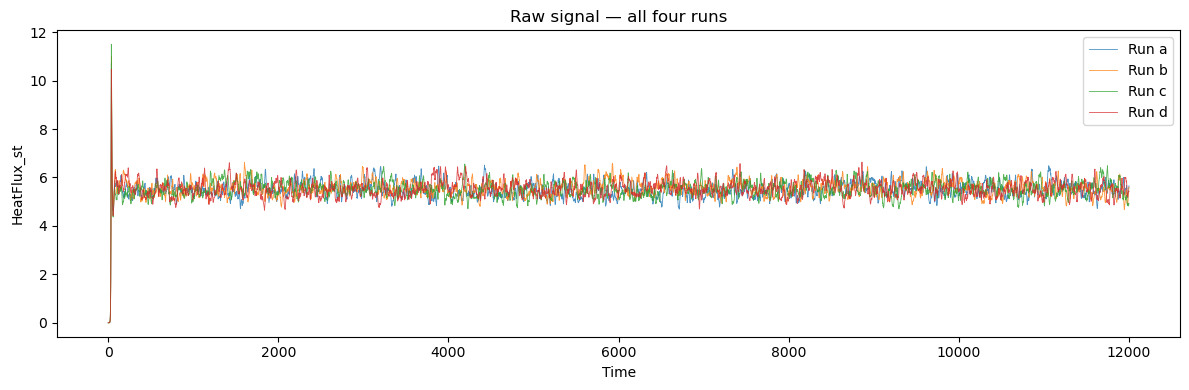

In [30]:
fig, ax = plt.subplots(figsize=(12, 4))

for label, ds in streams.items():
    ax.plot(
        ds.data["time"],
        ds.data[COLUMN],
        lw=0.6,
        alpha=0.8,
        color=COLOURS[label],
        label=f"Run {label}",
    )

ax.set_xlabel("Time")
ax.set_ylabel(COLUMN)
ax.set_title("Raw signal — all four runs")
ax.legend()
plt.tight_layout()
plt.show()

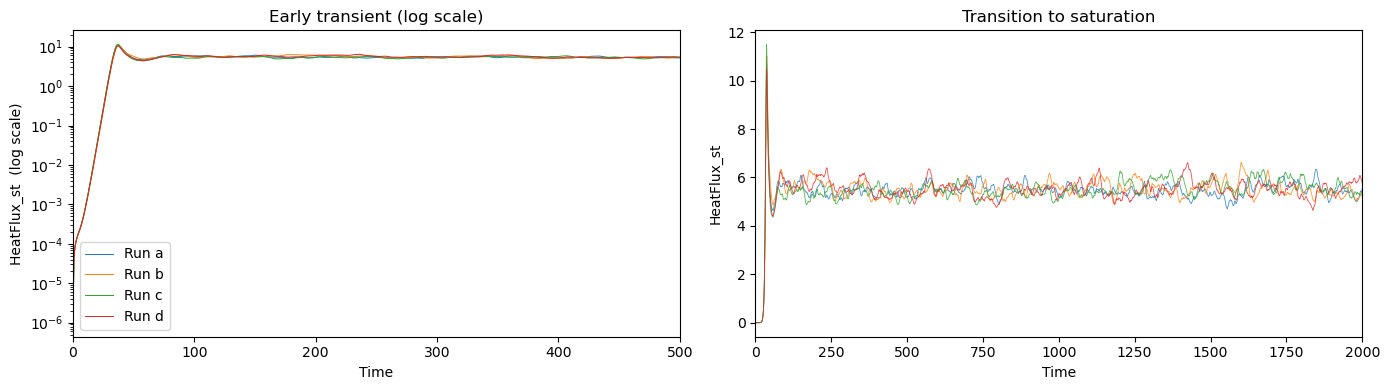

In [31]:
# Zoom into the early transient to see the growth phase
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, ds in streams.items():
    t = ds.data["time"]
    y = ds.data[COLUMN]
    axes[0].semilogy(t, y.clip(lower=1e-20), lw=0.7, color=COLOURS[label], label=f"Run {label}")
    axes[1].plot(t, y, lw=0.6, alpha=0.8, color=COLOURS[label])

axes[0].set_xlim(0, 500)
axes[0].set_xlabel("Time")
axes[0].set_ylabel(f"{COLUMN}  (log scale)")
axes[0].set_title("Early transient (log scale)")
axes[0].legend()

axes[1].set_xlim(0, 2000)
axes[1].set_xlabel("Time")
axes[1].set_ylabel(COLUMN)
axes[1].set_title("Transition to saturation")

plt.tight_layout()
plt.show()

## 4 — Trim Strategy 1: MeanVariationTrimStrategy (SSS)

**`MeanVariationTrimStrategy`** — the Statistical Steady-State (SSS) method.  
It detects the earliest point at which the signal's autocorrelation structure and variance become consistent with a stationary process.  This is the most physically motivated choice for gyrokinetic simulations.

```python
strategy = MeanVariationTrimStrategy(...)
op       = TrimDataStreamOperation(strategy=strategy)
trimmed  = op(ds, column_name="HeatFlux_st")
```

In [32]:
# Build the SSS strategy once — reuse it for all runs
sss_strategy = MeanVariationTrimStrategy(
    max_lag_frac=0.5,
    verbosity=1,           # prints the detected start time
    autocorr_sig_level=0.05,
    decor_multiplier=4.0,
    std_dev_frac=0.1,
    fudge_fac=0.1,
    smoothing_window_correction=0.3,
    final_smoothing_window=10,
)
sss_op = TrimDataStreamOperation(strategy=sss_strategy)

# Apply to every run
trimmed_sss = {}
for label, ds in streams.items():
    print(f"\n── Run {label} ──")
    trimmed_sss[label] = sss_op(ds, column_name=COLUMN)


── Run a ──
stats decorrelation length 291 gives smoothing window of 1164 points.
Getting start of SSS based on smoothed signal:
Index where criterion is met: 1163
Rolling window: 1164
time where criterion is met: 846.6117569582566
time at start of SSS (adjusted for rolling window): 592.1225385702685

── Run b ──
stats decorrelation length 277 gives smoothing window of 1108 points.
Getting start of SSS based on smoothed signal:
Index where criterion is met: 1107
Rolling window: 1108
time where criterion is met: 803.8037608887424
time at start of SSS (adjusted for rolling window): 561.8071894027997

── Run c ──
stats decorrelation length 311 gives smoothing window of 1244 points.
Getting start of SSS based on smoothed signal:
Index where criterion is met: 1243
Rolling window: 1244
time where criterion is met: 906.9730569554076
time at start of SSS (adjusted for rolling window): 633.0916536728863

── Run d ──
stats decorrelation length 310 gives smoothing window of 1240 points.
Getting 

In [33]:
# Report how much was dropped
print(f"{'Run':<6} {'Raw rows':>10} {'Trimmed rows':>14} {'Rows dropped':>14} {'Start time':>12}")
print("-" * 58)
for label in RUN_LABELS:
    raw     = streams[label]
    trimmed = trimmed_sss[label]
    n_raw   = len(raw.data)
    n_trim  = len(trimmed.data)
    t_start = trimmed.data["time"].iloc[0] if not trimmed.data.empty else float("nan")
    print(f"{label:<6} {n_raw:>10} {n_trim:>14} {n_raw - n_trim:>14} {t_start:>12.1f}")

Run      Raw rows   Trimmed rows   Rows dropped   Start time
----------------------------------------------------------
a           16472          15659            813        592.1
b           16508          15734            774        561.8
c           16490          15621            869        633.1
d           16501          15634            867        629.4


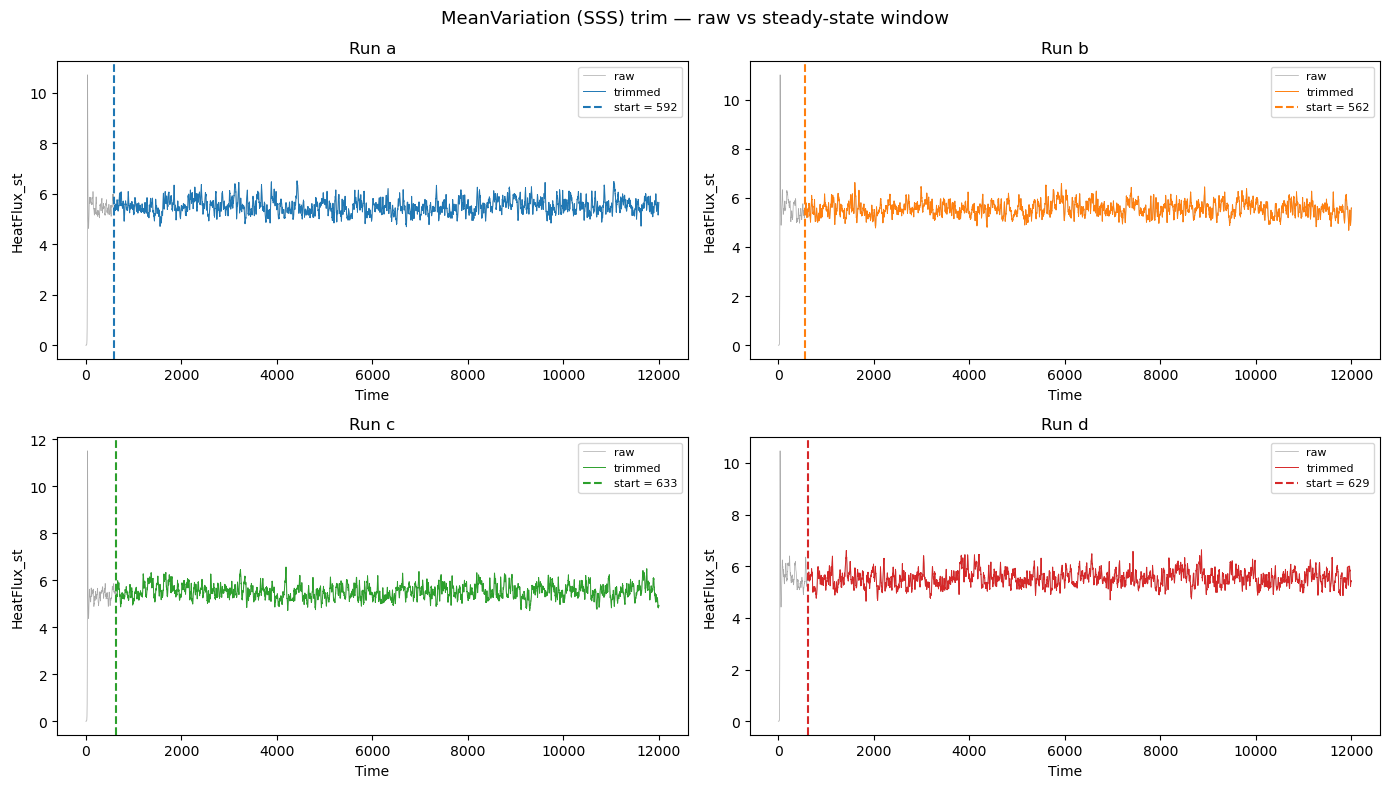

In [34]:
# Plot: raw signal with the detected steady-state start marked
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=False)
axes = axes.flatten()

for i, label in enumerate(RUN_LABELS):
    ax     = axes[i]
    ds     = streams[label]
    tr     = trimmed_sss[label]
    colour = COLOURS[label]

    ax.plot(ds.data["time"], ds.data[COLUMN], lw=0.5, color="#aaaaaa", label="raw")

    if not tr.data.empty:
        t_start = tr.data["time"].iloc[0]
        ax.plot(tr.data["time"], tr.data[COLUMN], lw=0.7, color=colour, label="trimmed")
        ax.axvline(t_start, color=colour, lw=1.5, ls="--", label=f"start = {t_start:.0f}")
    else:
        ax.text(0.5, 0.5, "No SSS found", transform=ax.transAxes, ha="center", color="red")

    ax.set_title(f"Run {label}")
    ax.set_xlabel("Time")
    ax.set_ylabel(COLUMN)
    ax.legend(fontsize=8)

fig.suptitle("MeanVariation (SSS) trim — raw vs steady-state window", fontsize=13)
plt.tight_layout()
plt.show()

## 5 — All Six Trim Strategies

quends provides six trim strategies.  They are all applied using the same pattern:

```python
op      = TrimDataStreamOperation(strategy=<strategy_instance>)
trimmed = op(ds, column_name="HeatFlux_st")
```

| Strategy | `method_name` | Core idea |
|---|---|---|
| `MeanVariationTrimStrategy` | `sss_start` | Autocorrelation + variance stationarity test (SSS) — see §4 |
| `QuantileTrimStrategy` | `std` | Robust MAD / classical 68-95-99 z-score criterion |
| `NoiseThresholdTrimStrategy` | `threshold` | Rolling std on normalised signal falls below a fixed threshold |
| `RollingVarianceThresholdTrimStrategy` | `rolling_variance` | Rolling std falls below a fraction of its own mean |
| `SelfConsistentTrimStrategy` | `self_consistent` | Consecutive non-overlapping blocks agree in mean and spread |
| `IQRTrimStrategy` | `iqr` | IQR of the remaining data ≤ threshold × \|median\| |

### Strategy 2 — QuantileTrimStrategy

Slides a window across the signal.  At each start position it evaluates the *remaining* data: with `robust=True` it checks whether the MAD z-scores satisfy a 95/99 % coverage criterion; with `robust=False` it uses the classical 68/95/99 normal-distribution rule.  The earliest start that passes is returned.

In [35]:
quantile_strategy = QuantileTrimStrategy(
    window_size=50,    # minimum points before criterion is evaluated
    robust=True,       # use MAD z-score instead of classical std rule
    start_time=100.0,  # skip the exponential growth phase entirely
)
quantile_op = TrimDataStreamOperation(strategy=quantile_strategy)

trimmed_q = {}
for label, ds in streams.items():
    trimmed_q[label] = quantile_op(ds, column_name=COLUMN)

print(f"{'Run':<6} {'Start time':>12} {'Trimmed rows':>14}")
print("-" * 34)
for label in RUN_LABELS:
    tr = trimmed_q[label]
    t0 = tr.data["time"].iloc[0] if not tr.data.empty else float("nan")
    print(f"{label:<6} {t0:>12.1f} {len(tr.data):>14}")

Run      Start time   Trimmed rows
----------------------------------
a             100.3          16332
b             100.4          16367
c             100.4          16351
d             100.0          16363


### Strategy 3 — NoiseThresholdTrimStrategy

Normalises the signal to zero mean and unit variance, then computes a rolling standard deviation.  The first time point where that rolling std falls below `threshold` is taken as the steady-state start.  Requires `threshold` to be set explicitly.

In [36]:
noise_strategy = NoiseThresholdTrimStrategy(
    window_size=200,   # rolling-std window (number of points)
    start_time=100.0,  # skip exponential growth
    threshold=0.3,     # rolling std on normalised signal must fall below 0.3
    robust=True,
)
noise_op = TrimDataStreamOperation(strategy=noise_strategy)

trimmed_noise = {}
for label, ds in streams.items():
    trimmed_noise[label] = noise_op(ds, column_name=COLUMN)

print(f"{'Run':<6} {'Start time':>12} {'Trimmed rows':>14}")
print("-" * 34)
for label in RUN_LABELS:
    tr = trimmed_noise[label]
    t0 = tr.data["time"].iloc[0] if not tr.data.empty else float("nan")
    print(f"{label:<6} {t0:>12.1f} {len(tr.data):>14}")

Run      Start time   Trimmed rows
----------------------------------
a             245.6          16133
b             243.9          16168
c             246.6          16152
d             242.9          16164


### Strategy 4 — RollingVarianceThresholdTrimStrategy

Computes a rolling standard deviation of the raw signal.  The threshold is expressed as a *fraction of the mean rolling std* over the whole window: the strategy looks for the first point where the local rolling std drops below `threshold × mean(rolling_std)`.  No normalisation step is needed.

In [50]:
rv_strategy = RollingVarianceThresholdTrimStrategy(
    window_size=50,   # rolling-std window (number of points)
    start_time=100.0,
    threshold=0.5,     # rolling_std < 0.1 × mean(rolling_std)
    robust=True,
)
rv_op = TrimDataStreamOperation(strategy=rv_strategy)

trimmed_rv = {}
for label, ds in streams.items():
    trimmed_rv[label] = rv_op(ds, column_name=COLUMN)

print(f"{'Run':<6} {'Start time':>12} {'Trimmed rows':>14}")
print("-" * 34)
for label in RUN_LABELS:
    tr = trimmed_rv[label]
    t0 = tr.data["time"].iloc[0] if not tr.data.empty else float("nan")
    print(f"{label:<6} {t0:>12.1f} {len(tr.data):>14}")

Run      Start time   Trimmed rows
----------------------------------
a             263.3          16109
b             344.6          16030
c             149.9          16283
d             230.1          16182


### Strategy 5 — SelfConsistentTrimStrategy

Divides the signal into consecutive non-overlapping blocks of size `window_size`.  Starting from the earliest block, it checks whether *all subsequent pairs* of blocks agree in mean (within `rel_tol_mu`) and spread (within `rel_tol_sigma`).  The earliest start of such a consistent sequence is returned.  Uses median + MAD when `robust=True`.

In [53]:
sc_strategy = SelfConsistentTrimStrategy(
    window_size=50,    # block size — large enough to capture turbulence statistics
    start_time=100.0,
    robust=True,
    rel_tol_mu=0.5,    # blocks must agree in mean within 5 %
    rel_tol_sigma=0.1,  # blocks must agree in spread within 10 %
)
sc_op = TrimDataStreamOperation(strategy=sc_strategy)

trimmed_sc = {}
for label, ds in streams.items():
    trimmed_sc[label] = sc_op(ds, column_name=COLUMN)

print(f"{'Run':<6} {'Start time':>12} {'Trimmed rows':>14}")
print("-" * 34)
for label in RUN_LABELS:
    tr = trimmed_sc[label]
    t0 = tr.data["time"].iloc[0] if not tr.data.empty else float("nan")
    print(f"{label:<6} {t0:>12.1f} {len(tr.data):>14}")

Run      Start time   Trimmed rows
----------------------------------
a           11870.6            180
b           11908.6            124
c           11910.6            124
d           11919.1            114


### Strategy 6 — IQRTrimStrategy

At each candidate start position it evaluates the *remaining* data tail.  The criterion is:

    IQR(remaining) ≤ threshold × |median(remaining)|

This fires as soon as the interquartile range of the remaining signal is small relative to its median — a model-free measure of how tightly the data is clustered.

In [51]:
iqr_strategy = IQRTrimStrategy(
    window_size=50,   # minimum points before criterion is evaluated
    start_time=100.0,
    threshold=0.05,    # IQR must be ≤ 5 % of |median|
)
iqr_op = TrimDataStreamOperation(strategy=iqr_strategy)

trimmed_iqr = {}
for label, ds in streams.items():
    trimmed_iqr[label] = iqr_op(ds, column_name=COLUMN)

print(f"{'Run':<6} {'Start time':>12} {'Trimmed rows':>14}")
print("-" * 34)
for label in RUN_LABELS:
    tr = trimmed_iqr[label]
    t0 = tr.data["time"].iloc[0] if not tr.data.empty else float("nan")
    print(f"{label:<6} {t0:>12.1f} {len(tr.data):>14}")

Run      Start time   Trimmed rows
----------------------------------
a           11794.2            285
b               nan              0
c           11950.3             69
d               nan              0


### Strategy comparison — all six

The cell below collects the detected start time for every strategy and every run into one table, then plots a grouped bar chart so differences are easy to spot.

In [40]:
# Collect all start times into a tidy DataFrame
all_trimmed = {
    "SSS (MeanVariation)": trimmed_sss,
    "Quantile (std)": trimmed_q,
    "NoiseThreshold": trimmed_noise,
    "RollingVariance": trimmed_rv,
    "SelfConsistent": trimmed_sc,
    "IQR": trimmed_iqr,
}

cmp_rows = []
for strategy_name, trimmed_dict in all_trimmed.items():
    for label in RUN_LABELS:
        tr = trimmed_dict[label]
        t0 = tr.data["time"].iloc[0] if not tr.data.empty else float("nan")
        cmp_rows.append({"Strategy": strategy_name, "Run": label, "Start time": t0})

cmp_df = pd.DataFrame(cmp_rows).pivot(index="Strategy", columns="Run", values="Start time")
cmp_df

Run,a,b,c,d
Strategy,,,,
IQR,11794.168304,NaN,NaN,NaN
NoiseThreshold,245.554384,243.883545,246.634842,242.853659
Quantile (std),100.345413,100.428946,100.367054,100.035643
RollingVariance,NaN,NaN,NaN,NaN
SSS (MeanVariation),592.122539,561.807189,633.091654,629.433152
SelfConsistent,7963.574410,10963.077073,9463.670440,9198.315161


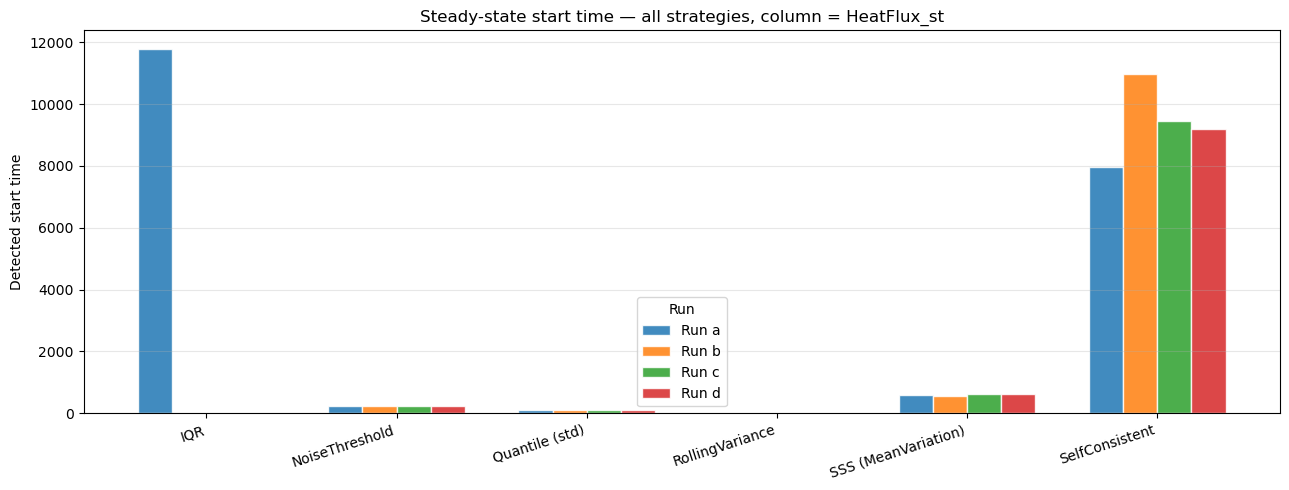

In [41]:
# Grouped bar chart: one group per strategy, one bar per run
import numpy as np

strategies = cmp_df.index.tolist()
n_strat    = len(strategies)
n_runs     = len(RUN_LABELS)
bar_w      = 0.18
x          = np.arange(n_strat)

fig, ax = plt.subplots(figsize=(13, 5))

for i, label in enumerate(RUN_LABELS):
    offsets = x + (i - n_runs / 2 + 0.5) * bar_w
    heights = [cmp_df.loc[s, label] for s in strategies]
    ax.bar(offsets, heights, width=bar_w, label=f"Run {label}",
           color=COLOURS[label], alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(strategies, rotation=18, ha="right", fontsize=10)
ax.set_ylabel("Detected start time")
ax.set_title(f"Steady-state start time — all strategies, column = {COLUMN}")
ax.legend(title="Run")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

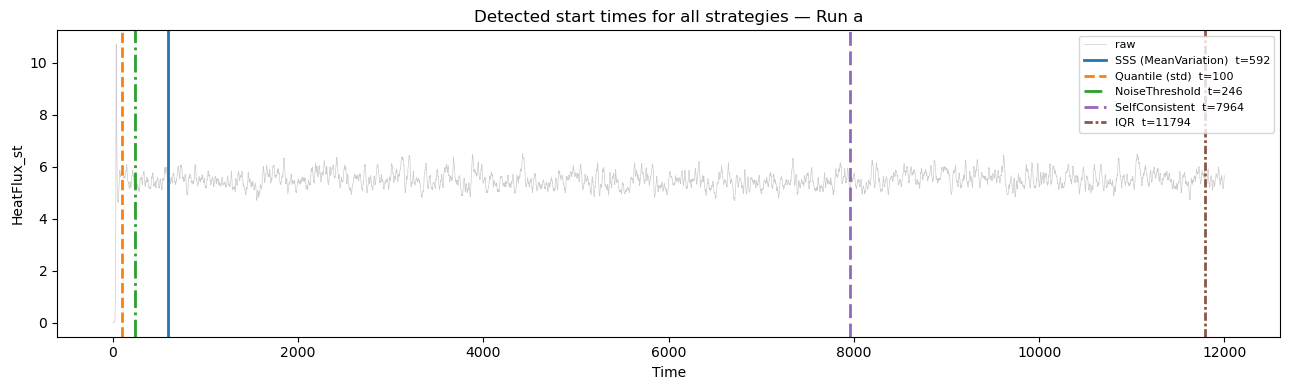

In [42]:
# Overlay all six detected start lines on run 'a' for a direct visual comparison
ref_label = "a"
ds_ref    = streams[ref_label]

STRATEGY_STYLES = {
    "SSS (MeanVariation)": (trimmed_sss,  "#1f77b4", "-"),
    "Quantile (std)":      (trimmed_q,    "#ff7f0e", "--"),
    "NoiseThreshold":      (trimmed_noise,"#2ca02c", "-."),
    "RollingVariance":     (trimmed_rv,   "#d62728", ":"),
    "SelfConsistent":      (trimmed_sc,   "#9467bd", (0,(5,2))),
    "IQR":                 (trimmed_iqr,  "#8c564b", (0,(3,1,1,1))),
}

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ds_ref.data["time"], ds_ref.data[COLUMN], lw=0.5, color="#cccccc", label="raw")

for name, (trimmed_dict, colour, ls) in STRATEGY_STYLES.items():
    tr = trimmed_dict[ref_label]
    if not tr.data.empty:
        t0 = tr.data["time"].iloc[0]
        ax.axvline(t0, color=colour, lw=2, ls=ls, label=f"{name}  t={t0:.0f}")

ax.set_xlabel("Time")
ax.set_ylabel(COLUMN)
ax.set_title(f"Detected start times for all strategies — Run {ref_label}")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## 6 — Compute Statistics on Trimmed Data

We use the **SSS-trimmed** DataStreams (MeanVariation) as the primary result — it is the most physically motivated choice.  
`compute_statistics` returns the mean, mean uncertainty (SE via Geyer ESS), 95 % confidence interval, ±1σ bounds, and effective sample size.

In [43]:
stats_results = {}

for label, tr in trimmed_sss.items():
    if tr.data.empty:
        print(f"Run {label}: trimmed DataStream is empty — skipping statistics.")
        stats_results[label] = None
        continue

    stats = tr.compute_statistics(column_name=COLUMN)
    stats_results[label] = stats

    col = stats.get(COLUMN, {})
    ci  = col.get("confidence_interval", (None, None))
    print(
        f"Run {label}: "
        f"mean = {col.get('mean', float('nan')):.5f}  "
        f"± {col.get('mean_uncertainty', float('nan')):.5f}  "
        f"CI = ({ci[0]:.5f}, {ci[1]:.5f})  "
        f"ESS = {col.get('effective_sample_size', '?')}"
    )

Run a: mean = 5.50916  ± 0.01545  CI = (5.47888, 5.53944)  ESS = 56
Run b: mean = 5.56515  ± 0.01557  CI = (5.53463, 5.59568)  ESS = 60
Run c: mean = 5.52502  ± 0.01619  CI = (5.49329, 5.55676)  ESS = 53
Run d: mean = 5.53642  ± 0.01565  CI = (5.50574, 5.56710)  ESS = 57


In [44]:
# Additional statistics: mean uncertainty and ESS separately
for label, tr in trimmed_sss.items():
    if tr.data.empty:
        continue
    mu  = tr.mean_uncertainty(column_name=COLUMN)
    ess = tr.effective_sample_size(column_names=[COLUMN])
    print(
        f"Run {label}: "
        f"SE = {mu[COLUMN]['mean_uncertainty']:.6f}  "
        f"window = {mu[COLUMN]['window_size']}  "
        f"ESS = {ess['results'][COLUMN]}"
    )

Run a: SE = 0.024729  window = 127  ESS = 56
Run b: SE = 0.019117  window = 145  ESS = 60
Run c: SE = 0.021387  window = 142  ESS = 53
Run d: SE = 0.020106  window = 127  ESS = 57


## 7 — Summary Table

Collect all key numbers into one DataFrame for easy comparison.

In [45]:
rows = []
for label in RUN_LABELS:
    raw = streams[label]
    tr  = trimmed_sss[label]
    res = stats_results.get(label)

    t_start = tr.data["time"].iloc[0] if (res is not None and not tr.data.empty) else float("nan")

    if res is not None and COLUMN in res:
        col = res[COLUMN]
        ci  = col.get("confidence_interval", (float("nan"), float("nan")))
        row = {
            "Run":           label,
            "Raw rows":      len(raw.data),
            "Trimmed rows":  len(tr.data),
            "SSS start":     round(t_start, 1),
            "Mean":          round(col.get("mean", float("nan")), 6),
            "SE":            round(col.get("mean_uncertainty", float("nan")), 6),
            "CI lower":      round(ci[0], 6),
            "CI upper":      round(ci[1], 6),
            "ESS":           col.get("effective_sample_size", None),
            "Window size":   col.get("window_size", None),
        }
    else:
        row = {"Run": label, "Raw rows": len(raw.data), "Trimmed rows": 0,
               "SSS start": float("nan"), "Mean": float("nan"), "SE": float("nan"),
               "CI lower": float("nan"), "CI upper": float("nan"), "ESS": None, "Window size": None}
    rows.append(row)

summary = pd.DataFrame(rows).set_index("Run")
summary

,Raw rows,Trimmed rows,SSS start,Mean,SE,CI lower,CI upper,ESS,Window size
Run,,,,,,,,,
a,16472,15659,592.1,5.509159,0.015450,5.478877,5.539441,56,127
b,16508,15734,561.8,5.565154,0.015573,5.534631,5.595678,60,145
c,16490,15621,633.1,5.525024,0.016190,5.493292,5.556757,53,142
d,16501,15634,629.4,5.536423,0.015653,5.505743,5.567104,57,127


## 8 — Visualise the Trimmed Means with Confidence Intervals

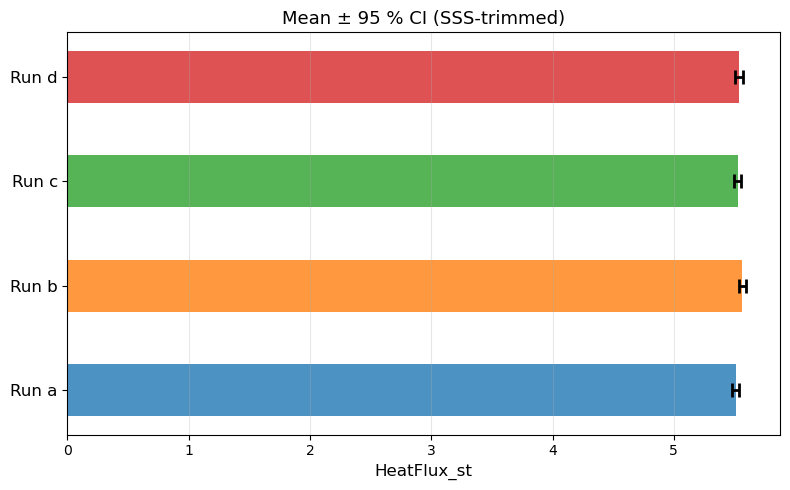

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

valid = summary.dropna(subset=["Mean"])

xerr_lower = valid["Mean"] - valid["CI lower"]
xerr_upper = valid["CI upper"] - valid["Mean"]

y_pos = range(len(valid))
ax.barh(
    y_pos,
    valid["Mean"],
    xerr=[xerr_lower.values, xerr_upper.values],
    align="center",
    height=0.5,
    color=[COLOURS[r] for r in valid.index],
    alpha=0.8,
    capsize=5,
    error_kw={"elinewidth": 2, "capthick": 2},
)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"Run {r}" for r in valid.index], fontsize=12)
ax.set_xlabel(COLUMN, fontsize=12)
ax.set_title("Mean ± 95 % CI (SSS-trimmed)", fontsize=13)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

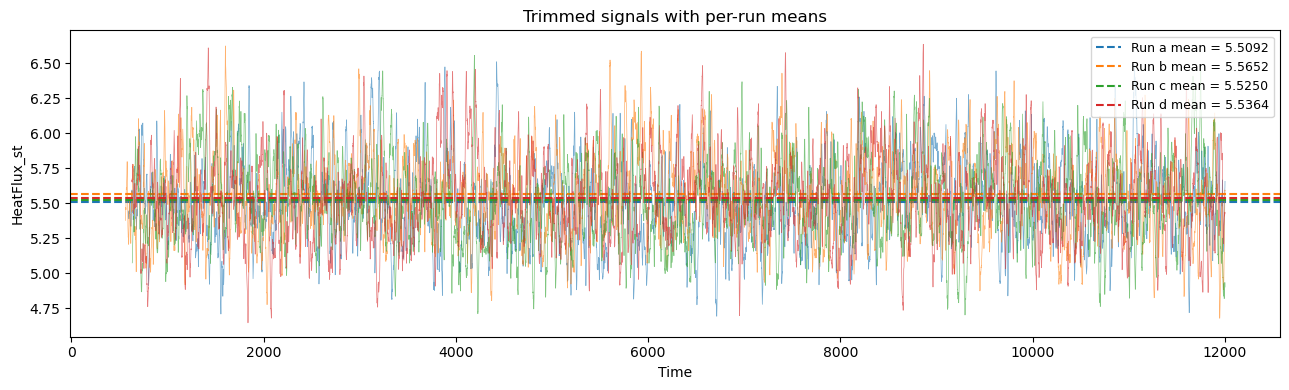

In [47]:
# Overlay all four trimmed signals with their means
fig, ax = plt.subplots(figsize=(13, 4))

for label in RUN_LABELS:
    tr = trimmed_sss[label]
    if tr.data.empty:
        continue
    colour = COLOURS[label]
    ax.plot(tr.data["time"], tr.data[COLUMN], lw=0.5, alpha=0.6, color=colour)
    if label in valid.index:
        mean_val = valid.loc[label, "Mean"]
        ax.axhline(mean_val, lw=1.5, ls="--", color=colour, label=f"Run {label} mean = {mean_val:.4f}")

ax.set_xlabel("Time")
ax.set_ylabel(COLUMN)
ax.set_title("Trimmed signals with per-run means")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9 — Repeat for a Second Column (optional)

All columns in the data set can be analysed the same way.  
Change `OTHER_COL` below to any column name from the list printed earlier.

In [48]:
OTHER_COL = "Wg_st"   # total wave energy — another commonly analysed quantity

other_op = TrimDataStreamOperation(strategy=sss_strategy)

other_rows = []
for label, ds in streams.items():
    tr    = other_op(ds, column_name=OTHER_COL)
    stats = tr.compute_statistics(column_name=OTHER_COL) if not tr.data.empty else {}
    col   = stats.get(OTHER_COL, {})
    ci    = col.get("confidence_interval", (float("nan"), float("nan")))
    other_rows.append({
        "Run":        label,
        "Mean":       round(col.get("mean", float("nan")), 8),
        "SE":         round(col.get("mean_uncertainty", float("nan")), 8),
        "CI lower":   round(ci[0], 8),
        "CI upper":   round(ci[1], 8),
        "ESS":        col.get("effective_sample_size", None),
    })

pd.DataFrame(other_rows).set_index("Run")

stats decorrelation length 376 gives smoothing window of 1504 points.
Getting start of SSS based on smoothed signal:
Index where criterion is met: 1503
Rolling window: 1504
time where criterion is met: 1094.4067933967349
time at start of SSS (adjusted for rolling window): 764.7176597461444
stats decorrelation length 348 gives smoothing window of 1392 points.
Getting start of SSS based on smoothed signal:
Index where criterion is met: 1391
Rolling window: 1392
time where criterion is met: 1011.3632120992072
time at start of SSS (adjusted for rolling window): 706.5745361131561
stats decorrelation length 410 gives smoothing window of 1640 points.
Getting start of SSS based on smoothed signal:
Index where criterion is met: 1639
Rolling window: 1640
time where criterion is met: 1195.2761813713985
time at start of SSS (adjusted for rolling window): 836.8338023211123
stats decorrelation length 392 gives smoothing window of 1568 points.
Getting start of SSS based on smoothed signal:
Index wher

,Mean,SE,CI lower,CI upper,ESS
Run,,,,,
a,139.840629,0.385783,139.084494,140.596763,44
b,141.178272,0.400246,140.393790,141.962755,49
c,140.498331,0.400918,139.712532,141.284130,40
d,140.555550,0.406498,139.758814,141.352286,44
